In [7]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb
import math

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src" / "context_scaling" / "scripts"))
sys.path.insert(0, str(REPO_ROOT / "src"))

## Helpers

In [8]:
def get_wandb_table(
    tags,
    project="ideas_cv/llm-random-test",
    negative_tags=None,
    columns=None,
    print_columns=False,
):
    # WandB automatically looks for the WANDB_API_KEY environment variable.
    api = wandb.Api()

    print(f"tags: {tags}")

    if isinstance(tags, str):
        tags = [tags]

    # $and ensures the run contains ALL of the specified positive tags.
    filters = {"$and": [{"tags": tag} for tag in tags]} if tags else {}

    runs = api.runs(path=project, filters=filters)

    runs_data = []
    for run in runs:
        run_dict = {
            "sys/id": run.id,
            "sys/name": run.name,
            "sys/state": run.state,
            "sys/tags": run.tags,
        }
        run_dict.update({f"config/{k}": v for k, v in run.config.items()})
        run_dict.update({f"summary/{k}": v for k, v in run.summary._json_dict.items()})

        runs_data.append(run_dict)

    runs_table = pd.DataFrame(runs_data)

    if runs_table.empty:
        print("df shape: (0, 0)")
        return runs_table

    if columns:
        cols_to_keep = set(columns)
        if negative_tags:
            cols_to_keep.add("sys/tags")

        available_cols = [col for col in cols_to_keep if col in runs_table.columns]
        runs_table = runs_table[available_cols]

    if negative_tags:
        if isinstance(negative_tags, str):
            negative_tags = [negative_tags]

        for neg_tag in negative_tags:
            runs_table = runs_table[
                ~runs_table["sys/tags"].apply(
                    lambda x: neg_tag in x if isinstance(x, list) else False
                )
            ]

    if print_columns:
        print("\n=== Available columns ===")
        for col in sorted(runs_table.columns):
            print(f"\t{col}")
        print("========================\n")

    print(f"df shape: {runs_table.shape}")

    return runs_table


def solve_config_lr(
    config_lr: float,
) -> tuple[
    float, float
]:  # TODO temporary place - move to devinitions eval+ when created
    ret_lr, ret_exp_lr = None, None
    if config_lr < 1.0:
        ret_lr = config_lr
        ret_exp_lr = -1 * math.log(config_lr) / math.log(2)
    if config_lr >= 1.0:
        ret_lr = 2**-config_lr
        ret_exp_lr = ret_exp_lr
    return ret_lr, ret_exp_lr


def flatten_config_columns(df: pd.DataFrame, sep: str = "/") -> pd.DataFrame:
    """Expand dict-valued `config/*` columns into flat columns.

    wandb stores the nested OmegaConf config, so `run.config.items()` yields
    top-level keys like `common`, `trainer` with dict values. This walks those
    dicts and produces columns like `config/trainer/learning_rate`.
    """
    df = df.copy()

    def walk(prefix, value, out):
        if isinstance(value, dict):
            for k, v in value.items():
                walk(f"{prefix}{sep}{k}", v, out)
        else:
            out[prefix] = value

    config_cols = [c for c in df.columns if c.startswith("config/")]
    new_rows = []
    for _, row in df.iterrows():
        flat = {}
        for c in config_cols:
            walk(c, row[c], flat)
        new_rows.append(flat)

    flat_df = pd.DataFrame(new_rows, index=df.index)
    df = df.drop(columns=config_cols)
    return pd.concat([df, flat_df], axis=1)

In [9]:
def get_final_loss_values(runs_table, lr_col, loss_col, main_variables):
    rows = []
    for _, run_row in runs_table.iterrows():
        row = {
            "run_id": run_row["sys/id"],
            "lr": run_row[lr_col],
            "final_loss": run_row[loss_col],
        }
        for i, mv in enumerate(main_variables):
            row[f"grid_val_{i}"] = run_row[mv]
        rows.append(row)
    return pd.DataFrame(rows)


def plot_loss_vs_lr(
    runs_table,
    main_variables,
    lr_col="config/trainer/learning_rate",
    loss_col="summary/steps/eval/loss",
    n_steps_col="config/trainer/n_steps",
    step_col="summary/step",
    ylim=None,
    title=None,
    ax=None,
    ax_labels_font=12,
    tick_font=12,
    title_font=12,
    var_labels=None,
    color_map=None,
    legend_loc="best",
):
    """Plot final eval loss vs learning rate, one line per `main_variables` combo.

    Expects a wandb-style dataframe (columns prefixed `config/` and `summary/`).
    Finished runs (step+1 >= n_steps) are drawn with circles + solid lines;
    running runs are drawn with squares + dashed lines.

    `color_map`, if given, maps grid-value tuples to colors so multiple calls
    can share a consistent palette across subplots.
    """
    color_dict = {
        0: "#1f78b4", 1: "#33a02c", 2: "#e31a1c", 3: "#ff7f00",
        4: "#6a3d9a", 5: "#a65628", 6: "#000000",
    }

    required = ["sys/id", lr_col, loss_col, n_steps_col, step_col, *main_variables]
    missing = [c for c in required if c not in runs_table.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    final_loss_df = get_final_loss_values(
        runs_table, lr_col=lr_col, loss_col=loss_col, main_variables=main_variables
    )
    final_loss_df = final_loss_df[final_loss_df["final_loss"].notnull()]

    completion_map = {
        r["sys/id"]: "complete" if (r[step_col] + 1 >= r[n_steps_col]) else "running"
        for _, r in runs_table.iterrows()
    }
    final_loss_df["status"] = final_loss_df["run_id"].map(completion_map)

    grid_cols = [f"grid_val_{i}" for i in range(len(main_variables))]
    grid_val_sets = (
        final_loss_df[grid_cols]
        .drop_duplicates()
        .sort_values(grid_cols)
        .itertuples(index=False, name=None)
    )

    var_labels = var_labels or {}

    for color_num, grid_vals in enumerate(grid_val_sets):
        mask = (final_loss_df[grid_cols] == grid_vals).all(axis=1)
        subset = final_loss_df[mask]
        color = color_map.get(grid_vals) if color_map is not None else color_dict.get(color_num)

        label = ", ".join(
            f"{var_labels.get(name, name)}: {value}"
            for name, value in zip(main_variables, grid_vals)
        )

        target = ax if ax is not None else plt

        finished = subset[subset["status"] == "complete"]
        if not finished.empty:
            means = finished.sort_values("lr").groupby("lr")["final_loss"].mean()
            target.plot(means.index.to_numpy(), means.values, marker="o",
                        color=color, label=label, linestyle="-")

        running = subset[subset["status"] != "complete"]
        if not running.empty:
            means = running.sort_values("lr").groupby("lr")["final_loss"].mean()
            target.plot(means.index.to_numpy(), means.values, marker="s",
                        color=color, label=label, linestyle="--", markersize=6)

    if ax is None:
        plt.legend(loc=legend_loc)
        plt.tick_params(axis="both", labelsize=tick_font)
        plt.xlabel("Learning Rate", fontsize=ax_labels_font)
        plt.ylabel("Final Eval Loss", fontsize=ax_labels_font)
        plt.title(title or "Final Loss vs Learning Rate", fontsize=title_font)
        plt.grid(True)
        plt.xscale("log", base=2)
        if ylim is not None:
            plt.ylim(ylim)
        plt.show()
    else:
        ax.legend(loc=legend_loc)
        ax.set_xlabel("Learning Rate", fontsize=ax_labels_font)
        ax.set_ylabel("Final Eval Loss", fontsize=ax_labels_font)
        ax.tick_params(axis="both", labelsize=tick_font)
        ax.set_xscale("log", base=2)
        ax.set_title(title or "Final Loss vs Learning Rate", fontsize=title_font)
        ax.grid(True)
        if ylim is not None:
            ax.set_ylim(ylim)

In [10]:
KEEP_COLS_DEFAULT = [
    "sys/id", "sys/name", "sys/state", "sys/tags",
    "config/trainer/learning_rate",
    "config/trainer/n_steps",
    "config/common/batch_size",
    "config/common/dmodel",
    "summary/step",
    "summary/steps/eval/loss",
]


def augment_with_midway_loss(
    df,
    project,
    pcts=(50,),
    metric_key="steps/eval/loss",
    n_steps_col="config/trainer/n_steps",
    cache_path=None,
    keep_cols=None,
):
    """Add `eval@<pct>` columns for eval loss at each pct% through training.

    Cache: if `cache_path` exists, values are read from CSV first; wandb history is
    only fetched for runs missing the requested pcts. The augmented df is then
    written back to `cache_path` with `keep_cols + eval@<pct>` columns.
    """
    pcts = list(pcts)
    target_cols = [f"eval@{p}" for p in pcts]

    cache = pd.DataFrame()
    if cache_path is not None and Path(cache_path).exists():
        cache = pd.read_csv(cache_path)
    cache_by_id = (
        {row["sys/id"]: row.to_dict() for _, row in cache.iterrows()}
        if "sys/id" in cache.columns
        else {}
    )

    api = wandb.Api()
    new_vals = {col: [] for col in target_cols}

    for _, run_row in df.iterrows():
        run_id = run_row["sys/id"]
        cached = cache_by_id.get(run_id, {})
        n_steps = run_row[n_steps_col]

        history = None
        for pct, col in zip(pcts, target_cols):
            cached_val = cached.get(col, np.nan)
            if pd.notnull(cached_val):
                new_vals[col].append(cached_val)
                continue

            if history is None:
                run = api.run(f"{project}/{run_id}")
                history = run.history(keys=[metric_key], samples=10000, pandas=True)

            if metric_key not in history.columns:
                new_vals[col].append(np.nan)
                continue

            h = history.dropna(subset=[metric_key])
            if h.empty:
                new_vals[col].append(np.nan)
                continue

            target_step = int(n_steps * pct / 100)
            idx = (h["_step"] - target_step).abs().idxmin()
            new_vals[col].append(h.loc[idx, metric_key])

    df = df.copy()
    for col in target_cols:
        df[col] = new_vals[col]

    if cache_path is not None:
        cols = list(keep_cols or KEEP_COLS_DEFAULT) + target_cols
        cols = [c for c in cols if c in df.columns]
        Path(cache_path).parent.mkdir(parents=True, exist_ok=True)
        df[cols].to_csv(cache_path, index=False)

    return df

## 1B LR grid

In [11]:
tags = ["1.7B", "qwen", "1B_train"]
negative_tags = ["remove"]
project = "ideas_cv/llm-random-test"

def resolve_lr(df):
    # config/trainer/learning_rate is the raw config value; solve_config_lr
    # maps x>=1 to 2**-x so the axis reflects the effective LR used in training.
    df = df.copy()
    df["config/trainer/learning_rate"] = df["config/trainer/learning_rate"].apply(
        lambda x: solve_config_lr(x)[0] if pd.notnull(x) else x
    )
    return df

df = get_wandb_table(tags, project=project, negative_tags=negative_tags)
print("df:", df.shape)


tags: ['1.7B', 'qwen', '1B_train']
df shape: (21, 115)
df: (21, 115)


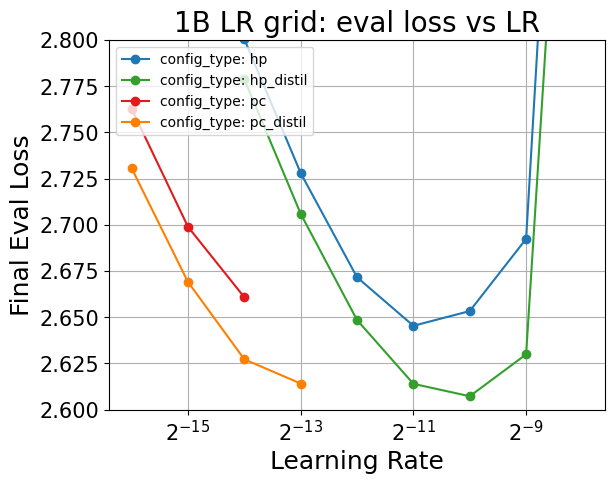

<Figure size 640x480 with 0 Axes>

In [13]:
# One plot, 4 curves (one per config). All four configs are uniquely identified by
# config/trainer/_target_:
#   PC (projected compression) vs HP (hard pruning)  x  distillation vs plain LM.
plot_df = flatten_config_columns(df)  # config/trainer is a nested dict from wandb

target = plot_df["config/trainer/_target_"].fillna("").astype(str)
plot_df["method"] = np.where(
    target.str.contains("projected_compression.trainer"), "PC", "HP"
)
plot_df["distillation"] = target.str.contains("distillation", case=False)
_labels = {
    ("PC", False): "pc", ("PC", True): "pc_distil",
    ("HP", False): "hp", ("HP", True): "hp_distil",
}
plot_df["config_type"] = [
    _labels[(m, d)] for m, d in zip(plot_df["method"], plot_df["distillation"])
]

plot_df = resolve_lr(plot_df)  # map raw config LR -> effective LR for the x-axis

mv = "config_type"
loss_col = "summary/steps/100/train/loss"

palette = ["#1f78b4", "#33a02c", "#e31a1c", "#ff7f00", "#6a3d9a", "#a65628", "#000000"]
config_types = sorted(plot_df[mv].dropna().unique())
color_map = {(ct,): palette[i % len(palette)] for i, ct in enumerate(config_types)}

ylim = (2.6, 2.8)

plot_loss_vs_lr(
    plot_df,
    main_variables=[mv],
    loss_col=loss_col,
    legend_loc="upper left",
    title="1B LR grid: eval loss vs LR",
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    color_map=color_map,
    ylim=ylim,
)

plt.tight_layout()
plt.show()
